In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

In [5]:
data = pd.read_csv("data.csv", index_col=0)
data.head()

,value
0,204
1,194
2,170
3,128
4,58


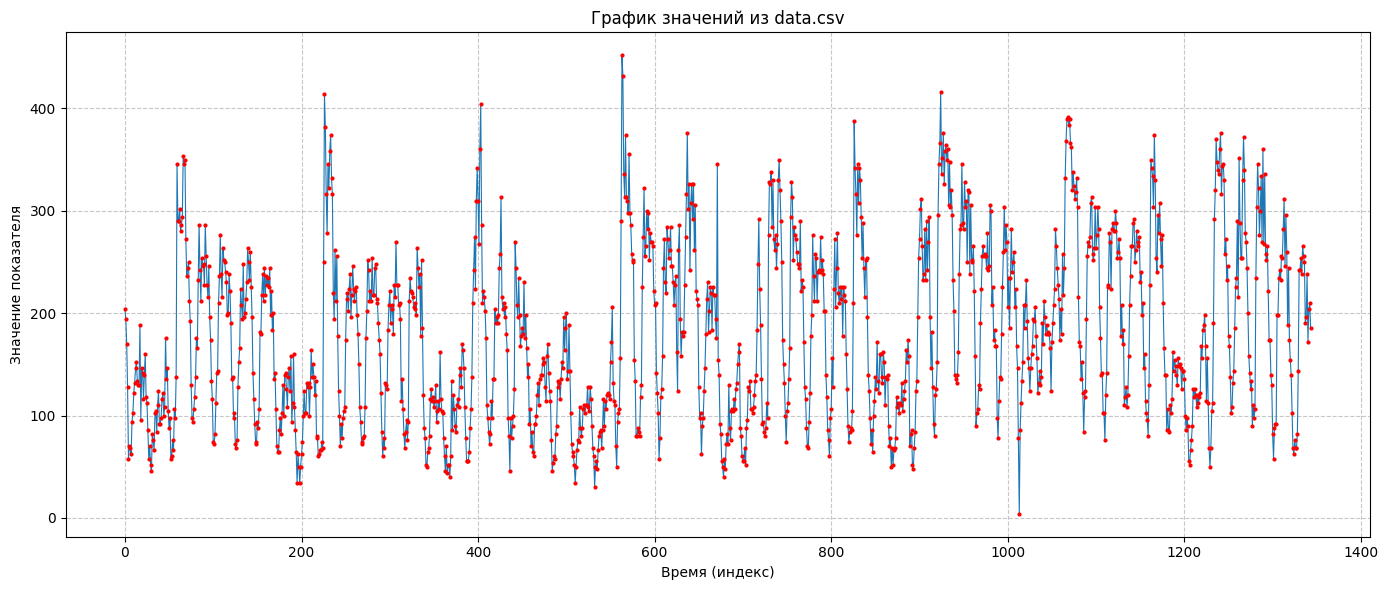

In [ ]:
a, b = 0, len(data)
x = data.index[a:b]
y = data["value"].values[a:b]
plt.figure(figsize=(14, 6))
plt.plot(
    x,
    y,
    "o-",
    markersize=2,
    linewidth=0.8,
    markerfacecolor="red",
    markeredgecolor="red",
)
plt.title("График значений из data.csv")
plt.xlabel("Время (индекс)")
plt.ylabel("Значение показателя")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
data = pd.read_csv("data.csv")
data.columns = ["ds", "y"]
start_date = "2023-01-01"
data["ds"] = pd.date_range(start=start_date, periods=len(data), freq="D")
train = data.iloc[:-336]
valid = data.iloc[-336:]

In [ ]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error
from math import sqrt


def test_prophet_params(fourier_order_24, fourier_order_168):
    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
    )

    model.add_seasonality(
        name="seasonality_24", period=24, fourier_order=fourier_order_24
    )
    model.add_seasonality(
        name="seasonality_168", period=168, fourier_order=fourier_order_168
    )

    model.fit(train)

    future = model.make_future_dataframe(periods=336, freq="D", include_history=False)
    forecast = model.predict(future)

    rmse = sqrt(mean_squared_error(valid["y"], forecast["yhat"]))
    return rmse, forecast

15:24:54 - cmdstanpy - INFO - Chain [1] start processing
15:24:54 - cmdstanpy - INFO - Chain [1] done processing
15:24:54 - cmdstanpy - INFO - Chain [1] start processing
15:24:54 - cmdstanpy - INFO - Chain [1] done processing
15:24:54 - cmdstanpy - INFO - Chain [1] start processing
15:24:55 - cmdstanpy - INFO - Chain [1] done processing
15:24:55 - cmdstanpy - INFO - Chain [1] start processing
15:24:55 - cmdstanpy - INFO - Chain [1] done processing
15:24:55 - cmdstanpy - INFO - Chain [1] start processing
15:24:55 - cmdstanpy - INFO - Chain [1] done processing
15:24:56 - cmdstanpy - INFO - Chain [1] start processing
15:24:56 - cmdstanpy - INFO - Chain [1] done processing
15:24:56 - cmdstanpy - INFO - Chain [1] start processing
15:24:56 - cmdstanpy - INFO - Chain [1] done processing
15:24:56 - cmdstanpy - INFO - Chain [1] start processing
15:24:56 - cmdstanpy - INFO - Chain [1] done processing
15:24:57 - cmdstanpy - INFO - Chain [1] start processing
15:24:57 - cmdstanpy - INFO - Chain [1]


Лучшие параметры: fourier_order_24=19, fourier_order_168=16
Лучший RMSE: 44.91


In [ ]:
param_combinations = [(i, j) for i in range(12, 23) for j in range(16, 26)]
rmses = np.zeros((10, 10))

best_rmse = float("inf")
best_params = None
best_forecast = None

for order_24, order_168 in param_combinations:
    rmse, forecast = test_prophet_params(order_24, order_168)
    rmses[(order_24 - 1) // 5, (order_168 - 1) // 5] = rmse

    if rmse < best_rmse:
        best_rmse = rmse
        best_params = (order_24, order_168)
        best_forecast = forecast

print(
    f"\nЛучшие параметры: fourier_order_24={best_params[0]}, fourier_order_168={best_params[1]}"
)
print(f"Лучший RMSE: {best_rmse:.2f}")

In [ ]:
final_model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
)
final_model.add_seasonality(
    name="seasonality_24", period=24, fourier_order=best_params[0]
)
final_model.add_seasonality(
    name="seasonality_168", period=168, fourier_order=best_params[1]
)
final_model.fit(data)

future = final_model.make_future_dataframe(periods=336, freq="D", include_history=False)
final_forecast = final_model.predict(future)

np.savetxt("forecast.txt", final_forecast["yhat"].values, fmt="%.6f")

15:19:50 - cmdstanpy - INFO - Chain [1] start processing
15:19:51 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
def test_prophet_advanced(
    fourier_order_24,
    fourier_order_168,
    changepoint_prior_scale,
    seasonality_prior_scale,
):
    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=changepoint_prior_scale,
        seasonality_prior_scale=seasonality_prior_scale,
        changepoint_range=0.95,  # 95% данных для определения точек изменения
        mcmc_samples=0,  # Отключаем MCMC для скорости
    )

    model.add_seasonality(
        name="seasonality_24",
        period=24,
        fourier_order=fourier_order_24,
        prior_scale=seasonality_prior_scale,
    )
    model.add_seasonality(
        name="seasonality_168",
        period=168,
        fourier_order=fourier_order_168,
        prior_scale=seasonality_prior_scale,
    )

    model.fit(train)

    future = model.make_future_dataframe(periods=336, freq="D", include_history=False)
    forecast = model.predict(future)

    rmse = sqrt(mean_squared_error(valid["y"], forecast["yhat"]))
    return rmse, forecast


# Тестируем разные комбинации регуляризации
advanced_params = []
for cp_scale in [0.001, 0.01, 0.05, 0.1]:
    for s_scale in [1.0, 5.0, 10.0, 20.0]:
        advanced_params.append((best_params[0], best_params[1], cp_scale, s_scale))

for params in advanced_params:
    rmse, forecast = test_prophet_advanced(*params)
    if rmse < best_rmse:
        best_rmse = rmse
        print(f"Улучшение: {params} - RMSE: {rmse:.2f}")

In [ ]:
(
    fourier_order_24,
    fourier_order_168,
    changepoint_prior_scale,
    seasonality_prior_scale,
) = 19, 16, 0.002, 0.999
model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=changepoint_prior_scale,
    seasonality_prior_scale=seasonality_prior_scale,
    changepoint_range=0.95,  # 95% данных для определения точек изменения
    mcmc_samples=0,  # Отключаем MCMC для скорости
)

model.add_seasonality(
    name="seasonality_24",
    period=24,
    fourier_order=fourier_order_24,
    prior_scale=seasonality_prior_scale,
)
model.add_seasonality(
    name="seasonality_168",
    period=168,
    fourier_order=fourier_order_168,
    prior_scale=seasonality_prior_scale,
)

model.fit(data)

future = model.make_future_dataframe(periods=336, freq="D", include_history=False)
forecast = model.predict(future)
np.savetxt("result.txt", forecast["yhat"].values, fmt="%.6f")

15:49:46 - cmdstanpy - INFO - Chain [1] start processing
15:49:46 - cmdstanpy - INFO - Chain [1] done processing


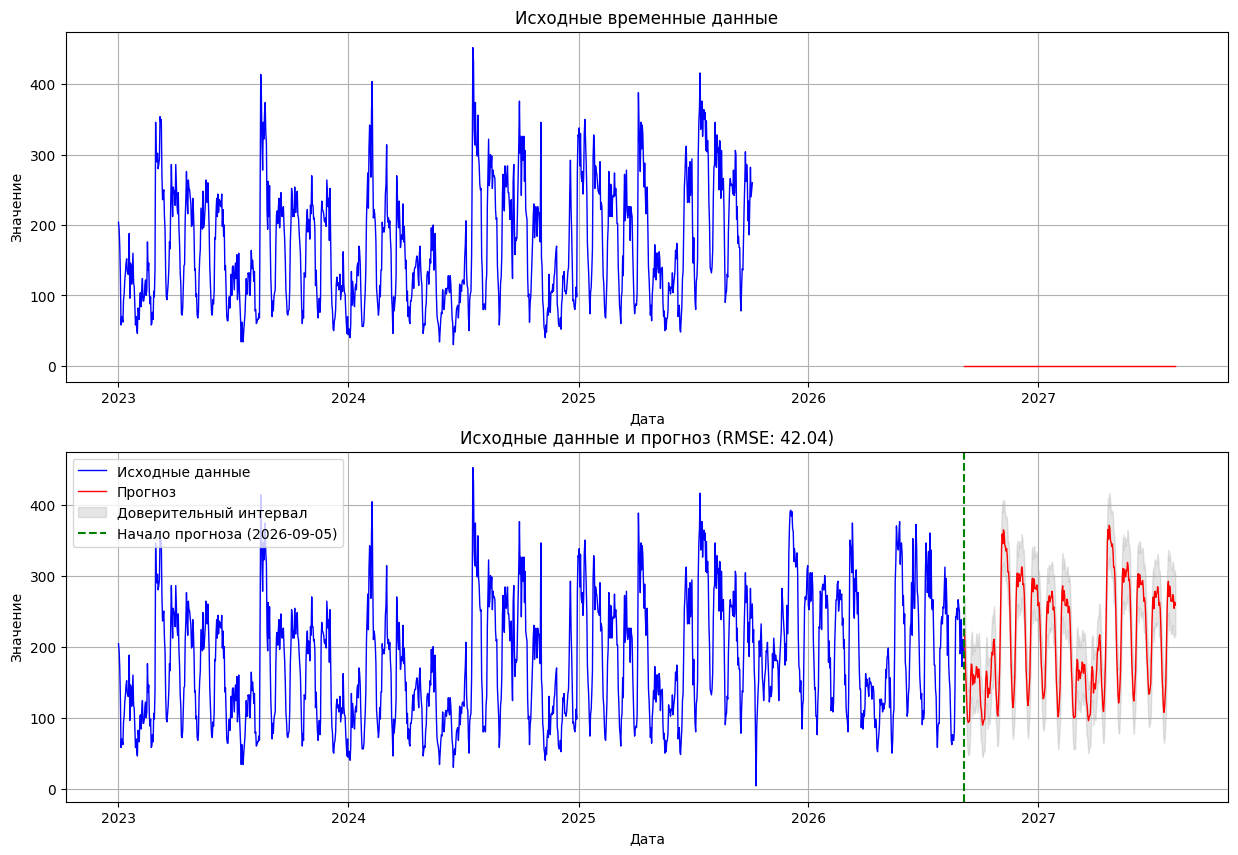

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(data["ds"][:-336], data["y"][:-336], "b-", linewidth=1)
plt.plot(forecast["ds"], np.zeros(len(forecast)), "r-", linewidth=1)
plt.title("Исходные временные данные")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(data["ds"], data["y"], "b-", linewidth=1, label="Исходные данные")
plt.plot(forecast["ds"], forecast["yhat"], "r-", linewidth=1, label="Прогноз")
plt.fill_between(
    forecast["ds"],
    forecast["yhat_lower"],
    forecast["yhat_upper"],
    alpha=0.2,
    color="gray",
    label="Доверительный интервал",
)

last_data_point = data["ds"].iloc[-1]
plt.axvline(
    x=last_data_point,
    color="green",
    linestyle="--",
    label=f"Начало прогноза ({last_data_point.strftime('%Y-%m-%d')})",
)

plt.title(f"Исходные данные и прогноз (RMSE: {best_rmse:.2f})")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.legend()
plt.grid(True)